# Analisis Proyeksi Perubahan Tutupan Lahan 2026 dengan Algoritma CA-Markov
Model prediksi tutupan lahan 2026 berbasis Cellular Automata - Markov Chain, dibatasi Area of Interest (AOI), faktor pendorong (MCE), dan faktor pembatas.

**Alur Kerja:**
import & Konfigurasi → Baca Legenda → Baca AOI → Mask AOI → Matriks Transisi Markov → MCE per Kelas → Fungsi CA-Markov → Validasi → Prediksi 2026 → Statistik Luas → Visualisasi → 5 File Output

**Output:**
1. Matriks_Transisi_Markov.xlsx — index & kolom = Classname
2. Confusion_Matrix_Validasi.xlsx — 3 sheet: Ringkasan, CM, Akurasi
3. Tutupan_Lahan_Prediksi_2026.tif — dengan RAT Classname
4. Statistik_Luas_Ha.xlsx — index = Classname
5. Grafik_Perubahan_Luas.png

## Import Library & Konfigurasi

In [1]:
import os, glob, warnings
import numpy as np, pandas as pd, geopandas as gpd, rasterio
from rasterio.features import rasterize
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy.ndimage import distance_transform_edt, uniform_filter
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# KONFIGURASI
# -----------------------------------------------------------------------------
DIR_RASTER    = r"D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\BAHAN\output"
DIR_PENDORONG = r"D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\BAHAN\Faktor Pendorong"
DIR_PEMBATAS  = r"D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\BAHAN\Faktor Pembatas"
DIR_OUTPUT    = r"D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\BAHAN\Output Prediksi Tutupan Lahan 2026"
AOI_PATH      = r"D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\aoi.shp"
os.makedirs(DIR_OUTPUT, exist_ok=True)

# --- Bersihkan output lama supaya hanya ada 5 file yang diminta ---
for f in glob.glob(os.path.join(DIR_OUTPUT, "*")):
    try:
        if os.path.isfile(f):
            os.remove(f)
    except Exception as e:
        print(f"  [skip] {os.path.basename(f)}: {e}")

TAHUN_PREDIKSI  = 2026
METODE_PROYEKSI = "CEA"     # "CEA" atau "UTM"

# --- Parameter CA ---
FILTER_SIZE     = 5
W_MCE           = 0.4
W_NEIGHBORHOOD  = 0.4
W_PROXIMITY     = 0.2

cari = lambda folder, pola: (glob.glob(os.path.join(folder, pola)) or [None])[0]
RASTER_2020 = cari(DIR_RASTER, "*2020*.tif")
RASTER_2023 = cari(DIR_RASTER, "*2023*.tif")
assert RASTER_2020 and RASTER_2023, "Raster 2020/2023 tidak ditemukan"
assert os.path.exists(AOI_PATH), f"AOI tidak ditemukan: {AOI_PATH}"
print("Raster 2020:", RASTER_2020)
print("Raster 2023:", RASTER_2023)
print("AOI        :", AOI_PATH)

Raster 2020: D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\BAHAN\output\Tutupan_Lahan_2020.tif
Raster 2023: D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\BAHAN\output\Tutupan_Lahan_2023.tif
AOI        : D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\aoi.shp


## Screening Nama Kelas
dari `Legenda_Kelas.csv` atau `.aux.xml`.

In [2]:
def baca_legenda(raster_path):
    csv_legenda = os.path.join(os.path.dirname(raster_path), "Legenda_Kelas.csv")
    if os.path.exists(csv_legenda):
        df = pd.read_csv(csv_legenda)
        return {int(k): str(v) for k, v in zip(df.iloc[:, 0], df.iloc[:, 1])}
    aux = raster_path + ".aux.xml"
    if os.path.exists(aux):
        import xml.etree.ElementTree as ET
        root = ET.parse(aux).getroot()
        nama_cat = [c.text for c in root.iter("Category")]
        return {i: nm for i, nm in enumerate(nama_cat) if i > 0}
    return {}

legenda = baca_legenda(RASTER_2023)
print("Legenda kelas:", legenda)

Legenda kelas: {1: 'Badan Air', 2: 'Permukiman', 3: 'Sawah', 4: 'Tanah Terbuka', 5: 'Vegetasi Tegakan'}


## 1. Baca AOI & Tentukan Grid Target dari Bounds AOI
Penyesuaian CRS agar otomatis terproyeksi ke CEA atau UTM

In [3]:
aoi = gpd.read_file(AOI_PATH)
print(f"\nAOI: {len(aoi)} fitur, CRS asli: {aoi.crs}")

with rasterio.open(RASTER_2023) as src:
    crs_asli = src.crs
    bounds_raster_asli = src.bounds

    if not crs_asli.is_geographic:
        crs = crs_asli
    elif METODE_PROYEKSI == "UTM":
        lon_c = (bounds_raster_asli.left + bounds_raster_asli.right) / 2
        lat_c = (bounds_raster_asli.bottom + bounds_raster_asli.top) / 2
        zona = int((lon_c + 180) // 6) + 1
        epsg = 32600 + zona if lat_c >= 0 else 32700 + zona
        crs = rasterio.crs.CRS.from_epsg(epsg)
    else:
        crs = rasterio.crs.CRS.from_proj4("+proj=cea +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs")
    print(f"CRS target: {crs}")

    transform_std, _, _ = calculate_default_transform(
        crs_asli, crs, src.width, src.height, *bounds_raster_asli
    )
    res_x = abs(transform_std.a)
    res_y = abs(transform_std.e)

# Reproyeksi AOI ke CRS target
aoi = aoi.to_crs(crs) if aoi.crs != crs else aoi
bounds_aoi = aoi.total_bounds
print(f"Bounds AOI: {bounds_aoi}")

# Grid target HANYA dari bounds AOI
width  = int(np.ceil((bounds_aoi[2] - bounds_aoi[0]) / res_x))
height = int(np.ceil((bounds_aoi[3] - bounds_aoi[1]) / res_y))
transform = rasterio.transform.from_origin(bounds_aoi[0], bounds_aoi[3], res_x, res_y)
print(f"Grid target: {width} x {height} piksel, resolusi {res_x:.2f} x {res_y:.2f} m")

nodata = 0
luas_px = abs(transform.a * transform.e)
print(f"Luas per piksel: {luas_px:.2f} m2")


AOI: 4 fitur, CRS asli: EPSG:4326
CRS target: PROJCS["unknown",GEOGCS["unknown",DATUM["Unknown based on WGS 84 ellipsoid",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Cylindrical_Equal_Area"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds AOI: [12792309.60960813  -974717.73247468 12843047.09187713  -908016.54316244]
Grid target: 5131 x 6746 piksel, resolusi 9.89 x 9.89 m
Luas per piksel: 97.78 m2


## 2. Pembatasan Area Analisis Dalam AOI

In [4]:
aoi_mask = rasterize(
    [(geom, 1) for geom in aoi.geometry if geom is not None],
    out_shape=(height, width), transform=transform,
    fill=0, dtype="uint8", all_touched=False,
)
print(f"\nMask AOI: {aoi_mask.sum():,} piksel = {aoi_mask.sum() * luas_px / 10000:,.2f} Ha")
assert aoi_mask.sum() > 0, "Mask AOI kosong!"


Mask AOI: 17,777,110 piksel = 173,829.50 Ha


## 3. Baca & Reproyeksi Raster 2020 & 2023, Clip ke AOI

In [5]:
def baca_reproyeksi_clip(path):
    with rasterio.open(path) as src:
        arr = np.full((height, width), nodata, dtype=src.dtypes[0])
        reproject(source=rasterio.band(src, 1), destination=arr,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=transform, dst_crs=crs, dst_nodata=nodata,
                  resampling=Resampling.nearest)
    arr[aoi_mask == 0] = nodata
    return arr

arr_2020 = baca_reproyeksi_clip(RASTER_2020)
arr_2023 = baca_reproyeksi_clip(RASTER_2023)

mask_studi = (arr_2020 != nodata) & (arr_2023 != nodata) & (aoi_mask == 1)
arr_2020[~mask_studi] = nodata
arr_2023[~mask_studi] = nodata

print(f"Piksel valid 2020: {np.sum(arr_2020 != nodata):,}")
print(f"Piksel valid 2023: {np.sum(arr_2023 != nodata):,}")
print(f"Area studi final : {mask_studi.sum():,} piksel = {mask_studi.sum() * luas_px / 10000:,.2f} Ha")

kelas = sorted((set(np.unique(arr_2020)) | set(np.unique(arr_2023))) - {nodata})
nama_unik, terpakai = {}, set()
for k in kelas:
    nm = legenda.get(int(k), f"Kelas_{k}")
    if nm in terpakai:
        nm = f"{nm}_{k}"
    terpakai.add(nm)
    nama_unik[k] = nm
nama = lambda k: nama_unik[k]
print("Kelas:", [nama(k) for k in kelas])

Piksel valid 2020: 17,777,110
Piksel valid 2023: 17,777,110
Area studi final : 17,777,110 piksel = 173,829.50 Ha
Kelas: ['Badan Air', 'Permukiman', 'Sawah', 'Tanah Terbuka', 'Vegetasi Tegakan']


## 4. Matriks Transisi Markov
Output: `Matriks_Transisi_Markov.xlsx`

In [6]:
a20 = arr_2020[mask_studi]
a23 = arr_2023[mask_studi]

matriks_piksel = pd.crosstab(a20, a23).reindex(index=kelas, columns=kelas, fill_value=0)
matriks_prob = matriks_piksel.div(matriks_piksel.sum(axis=1), axis=0)
for k in kelas:
    if matriks_piksel.loc[k].sum() == 0:
        matriks_prob.loc[k] = 0
        matriks_prob.loc[k, k] = 1
matriks_prob = matriks_prob.fillna(0)

# Label Classname
label_kelas = [nama(k) for k in kelas]
tabel_matriks = matriks_prob.copy()
tabel_matriks.index = label_kelas
tabel_matriks.columns = label_kelas
tabel_matriks.index.name = "Dari_Classname"
tabel_matriks.columns.name = "Ke_Classname"

print("\nMatriks Probabilitas Transisi Markov:")
print(tabel_matriks.round(3))
tabel_matriks.round(6).to_excel(os.path.join(DIR_OUTPUT, "Matriks_Transisi_Markov.xlsx"))


Matriks Probabilitas Transisi Markov:
Ke_Classname      Badan Air  Permukiman  Sawah  Tanah Terbuka  \
Dari_Classname                                                  
Badan Air             0.033       0.051  0.428          0.007   
Permukiman            0.003       0.689  0.243          0.029   
Sawah                 0.008       0.147  0.752          0.016   
Tanah Terbuka         0.008       0.411  0.246          0.299   
Vegetasi Tegakan      0.008       0.007  0.062          0.001   

Ke_Classname      Vegetasi Tegakan  
Dari_Classname                      
Badan Air                    0.481  
Permukiman                   0.036  
Sawah                        0.078  
Tanah Terbuka                0.037  
Vegetasi Tegakan             0.922  


## 5. Transition Potential (MCE per Kelas)
Faktor pendorong (vektor & raster) digabung jadi peta kesesuaian per classname; faktor pembatas digabung jadi mask area terlarang berubah.

In [7]:
def skor_dari_vektor(shp_path):
    gdf = gpd.read_file(shp_path)
    gdf = gdf.to_crs(crs) if gdf.crs != crs else gdf
    burned = rasterize([(g, 1) for g in gdf.geometry if g],
                       out_shape=(height, width), transform=transform, fill=0, dtype="uint8")
    jarak_m = distance_transform_edt(1 - burned) * abs(transform.a)
    return 1 - (jarak_m - jarak_m.min()) / (jarak_m.max() - jarak_m.min() + 1e-9)

def skor_dari_raster(tif_path):
    with rasterio.open(tif_path) as src:
        arr = np.zeros((height, width), dtype=np.float32)
        reproject(source=rasterio.band(src, 1), destination=arr,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=transform, dst_crs=crs, resampling=Resampling.bilinear)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

def kumpulkan_pendorong(folder):
    f_shp = sorted(glob.glob(os.path.join(folder, "*.shp")))
    f_tif = sorted(glob.glob(os.path.join(folder, "*.tif")))
    print(f"Faktor pendorong: {len(f_shp)} vektor + {len(f_tif)} raster")
    layers = [skor_dari_vektor(f) for f in f_shp] + [skor_dari_raster(f) for f in f_tif]
    return layers

skor_layers = kumpulkan_pendorong(DIR_PENDORONG)
assert skor_layers, "Tidak ada faktor pendorong"
N_FACTOR = len(skor_layers)

BOBOT_PER_KELAS = {k: np.ones(N_FACTOR) / N_FACTOR for k in kelas}
peta_mce_per_kelas = {}
for k in kelas:
    peta_mce_per_kelas[k] = np.tensordot(BOBOT_PER_KELAS[k], np.stack(skor_layers), axes=1)

def kumpulkan_pembatas(folder):
    f_shp = glob.glob(os.path.join(folder, "*.shp"))
    f_tif = glob.glob(os.path.join(folder, "*.tif"))
    mask = np.zeros((height, width), dtype=np.uint8)
    for f in f_shp:
        gdf = gpd.read_file(f)
        gdf = gdf.to_crs(crs) if gdf.crs != crs else gdf
        mask |= rasterize([(g, 1) for g in gdf.geometry if g],
                          out_shape=(height, width), transform=transform, fill=0, dtype="uint8")
    for f in f_tif:
        with rasterio.open(f) as src:
            arr = np.zeros((height, width), dtype=np.float32)
            reproject(source=rasterio.band(src, 1), destination=arr,
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=transform, dst_crs=crs, resampling=Resampling.nearest)
        mask |= (arr > 0).astype(np.uint8)
    return mask

mask_pembatas = kumpulkan_pembatas(DIR_PEMBATAS) & mask_studi.astype(np.uint8)

Faktor pendorong: 1 vektor + 1 raster


## 6. Fungsi Inti CA-Markov
Skor alokasi = kombinasi MCE + efek ketetanggaan (CA) + pola spasial classname, lalu piksel dialokasikan mengikuti proyeksi Markov (konservasi luas terjaga).

In [8]:
def pola_spasial_kelas(arr, k, mask_studi):
    arr_masked = np.where(mask_studi, arr, nodata)
    jarak = distance_transform_edt(arr_masked != k) * abs(transform.a)
    return 1 - (jarak - jarak.min()) / (jarak.max() - jarak.min() + 1e-9)

def efek_ketetanggaan(arr, k, mask_studi, size=FILTER_SIZE):
    biner = ((arr == k) & mask_studi).astype(np.float32)
    return uniform_filter(biner, size=size, mode="constant")

def hitung_skor_ca(arr_basis, k, mask_studi):
    return (W_MCE * peta_mce_per_kelas[k]
            + W_NEIGHBORHOOD * efek_ketetanggaan(arr_basis, k, mask_studi)
            + W_PROXIMITY   * pola_spasial_kelas(arr_basis, k, mask_studi))

def bulatkan_konservasi(nilai_float, total_target):
    lantai = np.floor(nilai_float).astype(int)
    sisa = int(round(total_target)) - lantai.sum()
    urutan = np.argsort(-(nilai_float - lantai))
    lantai[urutan[:max(sisa, 0)]] += 1
    return lantai

def proyeksi_jumlah(arr_basis, mat_prob, mask_studi):
    luas_basis = pd.Series({k: int(np.sum((arr_basis == k) & mask_studi)) for k in kelas})
    proyeksi = luas_basis.values @ mat_prob.values
    return pd.Series(bulatkan_konservasi(proyeksi, int(mask_studi.sum())), index=kelas)

def simulasi_ca(arr_basis, target_jumlah, mask_studi, mask_pembatas, verbose=True):
    luas_basis = pd.Series({k: int(np.sum((arr_basis == k) & mask_studi)) for k in kelas})
    selisih = (target_jumlah - luas_basis).astype(int)

    arr_hasil = arr_basis.copy()
    kelas_tumbuh   = selisih[selisih > 0].sort_values(ascending=False).index.tolist()
    kelas_menyusut = selisih[selisih < 0].index.tolist()

    boleh_berubah = mask_studi & (mask_pembatas == 0) & np.isin(arr_basis, kelas_menyusut)
    terpakai = np.zeros_like(boleh_berubah)

    if not kelas_tumbuh:
        if verbose: print("Tidak ada kelas yang tumbuh -> tidak ada alokasi.")
        return arr_hasil, selisih

    for k in kelas_tumbuh:
        n = int(selisih[k])
        skor = hitung_skor_ca(arr_basis, k, mask_studi)
        kandidat = np.flatnonzero(boleh_berubah & ~terpakai)
        if len(kandidat) < n:
            if verbose:
                print(f"  [PERINGATAN] {nama(k)}: butuh {n}, kandidat hanya {len(kandidat)}")
            n = len(kandidat)
        pilih = kandidat[np.argsort(-skor.ravel()[kandidat])[:n]]
        arr_hasil.ravel()[pilih] = k
        terpakai.ravel()[pilih] = True
        if verbose:
            print(f"  {nama(k):<25} teralokasi {len(pilih)}/{int(selisih[k])} piksel")

    arr_hasil[~mask_studi] = nodata
    return arr_hasil, selisih

## 7. Validasi
Model diuji dengan memprediksi 2023 dari basis 2020, lalu dibandingkan dengan 2023 aktual (Overall Accuracy, Kappa, Confusion Matrix).
Output: `Confusion_Matrix_Validasi.xlsx`

In [9]:
print("\n" + "="*70)
print("VALIDASI MODEL: prediksi 2023 dari basis 2020")
print("="*70)

target_2023_pred = proyeksi_jumlah(arr_2020, matriks_prob, mask_studi)
arr_2023_pred, _ = simulasi_ca(arr_2020, target_2023_pred, mask_studi, mask_pembatas, verbose=False)
arr_2023_pred[~mask_studi] = nodata


def hitung_metrik_validasi(aktual, prediksi, kelas_list, nodata, mask_studi):
    valid_mask = mask_studi & (aktual != nodata) & (prediksi != nodata)
    a = aktual[valid_mask].astype(int)
    p = prediksi[valid_mask].astype(int)

    n = len(kelas_list)
    idx = {k: i for i, k in enumerate(kelas_list)}
    cm = np.zeros((n, n), dtype=np.int64)
    for av, pv in zip(a, p):
        if av in idx and pv in idx:
            cm[idx[av], idx[pv]] += 1

    total = cm.sum()
    if total == 0: return None

    oa = np.trace(cm) / total
    row_sum = cm.sum(axis=1); col_sum = cm.sum(axis=0)
    ea = np.sum(row_sum * col_sum) / (total ** 2)
    kappa = (oa - ea) / (1 - ea) if (1 - ea) > 0 else 0

    pa = np.zeros(n); ua = np.zeros(n); f1 = np.zeros(n)
    for i in range(n):
        pa[i] = cm[i, i] / row_sum[i] if row_sum[i] > 0 else 0
        ua[i] = cm[i, i] / col_sum[i] if col_sum[i] > 0 else 0
        if (pa[i] + ua[i]) > 0:
            f1[i] = 2 * pa[i] * ua[i] / (pa[i] + ua[i])

    q_dis = np.sum(np.abs(row_sum - col_sum)) / (2 * total)
    a_dis = (1 - oa) - q_dis

    return {"OA": oa, "Kappa": kappa, "Expected_Agreement": ea,
            "Quantity_Disagree": q_dis, "Allocation_Disagree": a_dis,
            "PA": pa, "UA": ua, "F1": f1, "CM": cm, "Total_Piksel": total}


hasil = hitung_metrik_validasi(arr_2023, arr_2023_pred, kelas, nodata, mask_studi)

if hasil:
    print("\n--- RINGKASAN GLOBAL ---")
    print(f"  Total piksel valid   : {hasil['Total_Piksel']:,}")
    print(f"  Overall Accuracy (OA): {hasil['OA']:.4f}  ({hasil['OA']*100:.2f}%)")
    print(f"  Expected Agreement   : {hasil['Expected_Agreement']:.4f}")
    print(f"  Cohen's Kappa        : {hasil['Kappa']:.4f}")

    if hasil['Kappa'] >= 0.80:   status = "SANGAT BAIK (Almost Perfect)"
    elif hasil['Kappa'] >= 0.60: status = "BAIK (Substantial)"
    elif hasil['Kappa'] >= 0.40: status = "CUKUP (Moderate)"
    else:                         status = "LEMAH (Fair/Poor)"
    print(f"  Interpretasi Kappa   : {status}")
    print(f"\n  Quantity Disagreement  : {hasil['Quantity_Disagree']:.4f}")
    print(f"  Allocation Disagreement: {hasil['Allocation_Disagree']:.4f}")

    # Confusion matrix dengan Classname
    df_cm = pd.DataFrame(hasil["CM"],
                         index=[f"Aktual_{nama(k)}" for k in kelas],
                         columns=[f"Prediksi_{nama(k)}" for k in kelas])
    df_cm["Total_Aktual"] = df_cm.sum(axis=1)
    df_cm.loc["Total_Prediksi"] = df_cm.sum(axis=0)

    # Akurasi per kelas dengan Classname
    df_akurasi = pd.DataFrame({
        "Classname": [nama(k) for k in kelas],
        "Value": kelas,
        "Producer_Accuracy (PA)": hasil["PA"].round(4),
        "User_Accuracy (UA)":     hasil["UA"].round(4),
        "F1_Score":               hasil["F1"].round(4),
        "PA_%":                   (hasil["PA"] * 100).round(2),
        "UA_%":                   (hasil["UA"] * 100).round(2),
    }).set_index("Classname")

    print("\n--- CONFUSION MATRIX (piksel) ---")
    print(df_cm)
    print("\n--- AKURASI PER KELAS ---")
    print(df_akurasi.to_string())

    # Simpan Excel 3 sheet
    path_val = os.path.join(DIR_OUTPUT, "Confusion_Matrix_Validasi.xlsx")
    with pd.ExcelWriter(path_val, engine="openpyxl") as writer:
        pd.DataFrame({
            "Metrik": ["Total Piksel Valid", "Overall Accuracy (OA)",
                       "Expected Agreement", "Cohen's Kappa", "Interpretasi Kappa",
                       "Quantity Disagreement", "Allocation Disagreement"],
            "Nilai": [f"{hasil['Total_Piksel']:,}",
                      f"{hasil['OA']:.4f} ({hasil['OA']*100:.2f}%)",
                      f"{hasil['Expected_Agreement']:.4f}",
                      f"{hasil['Kappa']:.4f}",
                      status,
                      f"{hasil['Quantity_Disagree']:.4f}",
                      f"{hasil['Allocation_Disagree']:.4f}"],
        }).to_excel(writer, sheet_name="Ringkasan_Global", index=False)
        df_cm.to_excel(writer, sheet_name="Confusion_Matrix")
        df_akurasi.to_excel(writer, sheet_name="Akurasi_Per_Kelas")
    print(f"\nHasil validasi -> {path_val}")
else:
    print("Validasi gagal: tidak ada piksel valid.")


VALIDASI MODEL: prediksi 2023 dari basis 2020

--- RINGKASAN GLOBAL ---
  Total piksel valid   : 17,777,110
  Overall Accuracy (OA): 0.7629  (76.29%)
  Expected Agreement   : 0.3620
  Cohen's Kappa        : 0.6284
  Interpretasi Kappa   : BAIK (Substantial)

  Quantity Disagreement  : 0.0000
  Allocation Disagreement: 0.2371

--- CONFUSION MATRIX (piksel) ---
                         Prediksi_Badan Air  Prediksi_Permukiman  \
Aktual_Badan Air                      42472                13902   
Aktual_Permukiman                      3094              1873105   
Aktual_Sawah                          23916               741336   
Aktual_Tanah Terbuka                    320                80873   
Aktual_Vegetasi Tegakan              127804               191790   
Total_Prediksi                       197606              2901006   

                         Prediksi_Sawah  Prediksi_Tanah Terbuka  \
Aktual_Badan Air                  59381                    6234   
Aktual_Permukiman         

## 8. Prediksi 2026
Output: `Tutupan_Lahan_Prediksi_2026.tif` (dengan RAT Classname)

In [10]:
print("\n" + "="*70)
print(f"PREDIKSI {TAHUN_PREDIKSI}")
print("="*70)

target_2026 = proyeksi_jumlah(arr_2023, matriks_prob, mask_studi)
arr_2026, selisih_2026 = simulasi_ca(arr_2023, target_2026, mask_studi, mask_pembatas, verbose=True)
arr_2026[~mask_studi] = nodata

path_out = os.path.join(DIR_OUTPUT, f"Tutupan_Lahan_Prediksi_{TAHUN_PREDIKSI}.tif")
profile_out = {
    "driver": "GTiff", "height": height, "width": width,
    "transform": transform, "crs": crs,
    "count": 1, "dtype": "uint8", "compress": "lzw", "nodata": nodata,
}
with rasterio.open(path_out, "w", **profile_out) as dst:
    dst.write(arr_2026.astype("uint8"), 1)

# --- Tambahkan RAT (Raster Attribute Table) dengan Classname ---
rat_data = []
for k in kelas:
    count = int(np.sum((arr_2026 == k) & mask_studi))
    rat_data.append({
        "Value": int(k),
        "Classname": nama(k),
        "Count": count,
        "Luas_Ha": round(count * luas_px / 10000, 2),
    })

with rasterio.open(path_out, "r+") as dst:
    # Tulis RAT sebagai tag "RAT_<value>" = "Classname|Count|Luas_Ha"
    for r in rat_data:
        dst.update_tags(1, **{
            f"RAT_{r['Value']:03d}": f"{r['Classname']}|{r['Count']}|{r['Luas_Ha']}"
        })
    # Simpan juga sebagai metadata global untuk kemudahan
    dst.update_tags(
        CLASSNAMES=";".join([f"{r['Value']}={r['Classname']}" for r in rat_data]),
        TAHUN_PREDIKSI=str(TAHUN_PREDIKSI),
    )

print("Raster prediksi (dengan RAT Classname) ->", path_out)


PREDIKSI 2026
  Permukiman                teralokasi 189061/189061 piksel
  Vegetasi Tegakan          teralokasi 60467/60467 piksel
  Tanah Terbuka             teralokasi 20662/20662 piksel
Raster prediksi (dengan RAT Classname) -> D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\BAHAN\Output Prediksi Tutupan Lahan 2026\Tutupan_Lahan_Prediksi_2026.tif


## 9. Statistik Luas
Output: `Statistik_Luas_Ha.xlsx`, termasuk verifikasi konservasi luas total.

In [11]:
def hitung_luas(arr, k, mask_studi):
    return int(np.sum((arr == k) & mask_studi)) * (luas_px / 10000)

stat = pd.DataFrame({
    "Value": kelas,
    "Classname": [nama(k) for k in kelas],
    "Ha_2020": [hitung_luas(arr_2020, k, mask_studi) for k in kelas],
    "Ha_2023": [hitung_luas(arr_2023, k, mask_studi) for k in kelas],
    f"Ha_{TAHUN_PREDIKSI}": [hitung_luas(arr_2026, k, mask_studi) for k in kelas],
})
stat[f"Perubahan_2023-{TAHUN_PREDIKSI}_Ha"] = stat[f"Ha_{TAHUN_PREDIKSI}"] - stat["Ha_2023"]
stat = stat.set_index("Classname").round(2)

stat.to_excel(os.path.join(DIR_OUTPUT, "Statistik_Luas_Ha.xlsx"))
print("\n", stat)

# Verifikasi konservasi
total_2020 = stat["Ha_2020"].sum()
total_2023 = stat["Ha_2023"].sum()
total_2026 = stat[f"Ha_{TAHUN_PREDIKSI}"].sum()
print("\n--- VERIFIKASI KONSERVASI LUAS (DALAM AOI) ---")
print(f"  Total luas 2020: {total_2020:,.2f} Ha")
print(f"  Total luas 2023: {total_2023:,.2f} Ha")
print(f"  Total luas {TAHUN_PREDIKSI}: {total_2026:,.2f} Ha")
if abs(total_2020 - total_2026) < 0.01:
    print("  STATUS: KONSISTEN")
else:
    print(f"  STATUS: TIDAK KONSISTEN (selisih {abs(total_2020 - total_2026):.2f} Ha)")


                   Value   Ha_2020   Ha_2023   Ha_2026  Perubahan_2023-2026_Ha
Classname                                                                    
Badan Air             1  28424.77   1932.25   1788.24                 -144.00
Permukiman            2  26387.47  28366.84  30215.53                 1848.69
Sawah                 3  50765.70  61337.39  58839.40                -2497.99
Tanah Terbuka         4   1954.92   2436.20   2638.24                  202.04
Vegetasi Tegakan      5  66296.64  79756.83  80348.09                  591.26

--- VERIFIKASI KONSERVASI LUAS (DALAM AOI) ---
  Total luas 2020: 173,829.50 Ha
  Total luas 2023: 173,829.51 Ha
  Total luas 2026: 173,829.50 Ha
  STATUS: KONSISTEN


## 10. Grafik Perubahan Luas
Output: `Grafik_Perubahan_Luas.png`

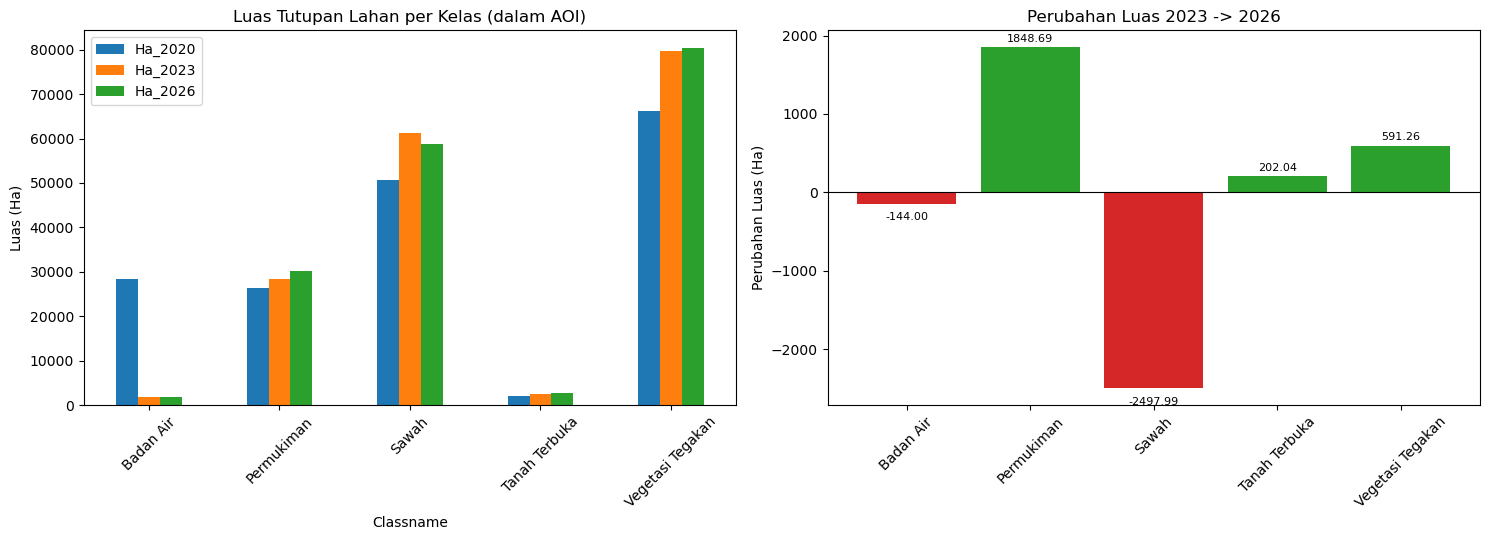


SELESAI -> D:\AUZAIE\LAMAR KERJA\LAMAR GAWEAN\LAMAR KERJAAN\LAMAR GIS ANALYST ILLAPS\BAHAN TES\BAHAN\Output Prediksi Tutupan Lahan 2026

File output final:
  - Confusion_Matrix_Validasi.xlsx
  - Grafik_Perubahan_Luas.png
  - Matriks_Transisi_Markov.xlsx
  - Statistik_Luas_Ha.xlsx
  - Tutupan_Lahan_Prediksi_2026.tif


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Kiri: luas per tahun
stat[["Ha_2020", "Ha_2023", f"Ha_{TAHUN_PREDIKSI}"]].plot(kind="bar", ax=axes[0])
axes[0].set_ylabel("Luas (Ha)")
axes[0].set_title("Luas Tutupan Lahan per Kelas (dalam AOI)")
axes[0].tick_params(axis="x", rotation=45)

# Kanan: perubahan 2023 -> 2026
delta = stat[f"Perubahan_2023-{TAHUN_PREDIKSI}_Ha"]
warna = delta.apply(lambda v: "tab:green" if v > 0 else ("tab:red" if v < 0 else "tab:gray"))
batang = axes[1].bar(stat.index, delta, color=warna)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Perubahan Luas (Ha)")
axes[1].set_title(f"Perubahan Luas 2023 -> {TAHUN_PREDIKSI}")
axes[1].tick_params(axis="x", rotation=45)
for b, v in zip(batang, delta):
    axes[1].annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v),
                     textcoords="offset points",
                     xytext=(0, 4 if v >= 0 else -12),
                     ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUT, "Grafik_Perubahan_Luas.png"), dpi=150)
plt.show()

print("\n" + "="*70)
print("SELESAI ->", DIR_OUTPUT)
print("="*70)

# --- Konfirmasi output final ---
print("\nFile output final:")
for f in sorted(glob.glob(os.path.join(DIR_OUTPUT, "*"))):
    print(f"  - {os.path.basename(f)}")